In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.20.0


In [ ]:
observations = 100000
xs = np.random.uniform(low=-10,high=10, size=(observations,1))
zs = np.random.uniform(low=-10,high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)


(100000, 2)


In [ ]:
noise = np.random.uniform(low=-1,high=1, size=(observations,1))
targets = 13 * xs + 7 * zs - 12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(100000, 1)


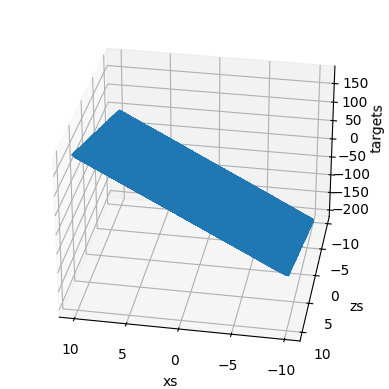

In [ ]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('targets')
ax.view_init(azim=100)
plt.show()

In [ ]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights,biases)

[[-0.09379657]
 [-0.05880916]] [0.05204488]


In [ ]:
targets = targets.reshape(observations,1)
eta = 0.01
for i in range (100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2)/2/observations
  print(loss)
  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

3761.885209854845
1712.6883484957843
800.1528608096119
393.37463197843306
211.64168381878463
130.05471771148314
93.0410710567577
75.87404923992672
67.55149380998229
63.17782644077601
60.57453246750791
58.77203378874721
57.3386633013044
56.08209834383252
54.91651597056889
53.80348461147819
52.72566411918129
51.675103663056866
50.64803484078517
49.64255480160623
48.65759526817511
47.692463715737865
46.74663913273552
45.81968105860333
44.91118902582151
44.020784430993096
43.14810238737027
42.292788020251564
41.45449474082233
40.63288340185797
39.82762184733219
39.03838463878199
38.26485286177872
37.506713969471406
36.76366164402511
36.03539566739396
35.32162179759262
34.62205164873146
33.9364025740192
33.264397551351095
32.60576507128871
31.960239027319773
31.327558608324736
30.70746819319311
30.099717247541438
29.50406022248856
28.920256455445987
28.348070072883075
27.78726989502705
27.237629342459723
26.698926344572833
26.170943249845234
25.653466737905177
25.146287733342913
24.64920132

In [ ]:
print (weights, biases)

[[13.00442033]
 [ 7.00077547]] [-7.59416337]


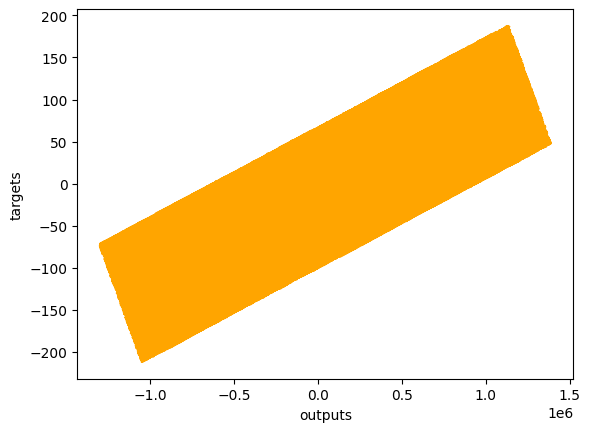

In [ ]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()